# Project Overview: Song BPM Prediction

**Objective:** Predict the tempo of tracks (`BeatsPerMinute`) using audio features, structural characteristics, and metadata dynamics.

## 1. Libraries & Workspace Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s5e9')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s5e9


In [2]:
#!pip install "numpy<2" "scikit-learn==1.3.2" --force-reinstall

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
import pickle
import joblib

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [4]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e9/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s5e9/test.csv')

In [5]:
train_df.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [6]:
test_df.head()

,id,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy
0,524164,0.410013,-16.794967,0.023500,0.232910,0.012689,0.271585,0.664321,302901.5498,0.424867
1,524165,0.463071,-1.357000,0.141818,0.057725,0.257942,0.097624,0.829552,221995.6643,0.846000
2,524166,0.686569,-3.368928,0.167851,0.287823,0.210915,0.325909,0.304978,357724.0127,0.134067
3,524167,0.885793,-5.598049,0.118488,0.000005,0.376906,0.134435,0.487740,271790.3989,0.316467
4,524168,0.637391,-7.068160,0.126099,0.539073,0.068950,0.024300,0.591248,277728.5383,0.481067


### 2.2. Checking Structural Metadata

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524164 entries, 0 to 524163
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         524164 non-null  int64  
 1   RhythmScore                524164 non-null  float64
 2   AudioLoudness              524164 non-null  float64
 3   VocalContent               524164 non-null  float64
 4   AcousticQuality            524164 non-null  float64
 5   InstrumentalScore          524164 non-null  float64
 6   LivePerformanceLikelihood  524164 non-null  float64
 7   MoodScore                  524164 non-null  float64
 8   TrackDurationMs            524164 non-null  float64
 9   Energy                     524164 non-null  float64
 10  BeatsPerMinute             524164 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 44.0 MB


In [8]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174722 entries, 0 to 174721
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         174722 non-null  int64  
 1   RhythmScore                174722 non-null  float64
 2   AudioLoudness              174722 non-null  float64
 3   VocalContent               174722 non-null  float64
 4   AcousticQuality            174722 non-null  float64
 5   InstrumentalScore          174722 non-null  float64
 6   LivePerformanceLikelihood  174722 non-null  float64
 7   MoodScore                  174722 non-null  float64
 8   TrackDurationMs            174722 non-null  float64
 9   Energy                     174722 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 13.3 MB


In [9]:
train_df.shape

(524164, 11)

In [10]:
test_df.shape

(174722, 10)

In [11]:
train_df.isnull().sum()

id                           0
RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
BeatsPerMinute               0
dtype: int64

In [12]:
test_df.isnull().sum()

id                           0
RhythmScore                  0
AudioLoudness                0
VocalContent                 0
AcousticQuality              0
InstrumentalScore            0
LivePerformanceLikelihood    0
MoodScore                    0
TrackDurationMs              0
Energy                       0
dtype: int64

## 3. Exploratory Data Analysis

In [30]:
train_df.drop(columns=['id']).describe().T

,count,mean,std,min,25%,50%,75%,max
RhythmScore,524164.0,0.632843,0.156899,0.076900,0.515850,0.634686,0.739179,0.975000
AudioLoudness,524164.0,-8.379014,4.616221,-27.509725,-11.551933,-8.252499,-4.912298,-1.357000
VocalContent,524164.0,0.074443,0.049939,0.023500,0.023500,0.066425,0.107343,0.256401
AcousticQuality,524164.0,0.262913,0.223120,0.000005,0.069413,0.242502,0.396957,0.995000
InstrumentalScore,524164.0,0.117690,0.131845,0.000001,0.000001,0.074247,0.204065,0.869258
LivePerformanceLikelihood,524164.0,0.178398,0.118186,0.024300,0.077637,0.166327,0.268946,0.599924
MoodScore,524164.0,0.555843,0.225480,0.025600,0.403921,0.564817,0.716633,0.978000
TrackDurationMs,524164.0,241903.692949,59326.601501,63973.000000,207099.876625,243684.058150,281851.658500,464723.228100
Energy,524164.0,0.500923,0.289952,0.000067,0.254933,0.511800,0.746000,1.000000
BeatsPerMinute,524164.0,119.034899,26.468077,46.718000,101.070410,118.747660,136.686590,206.037000


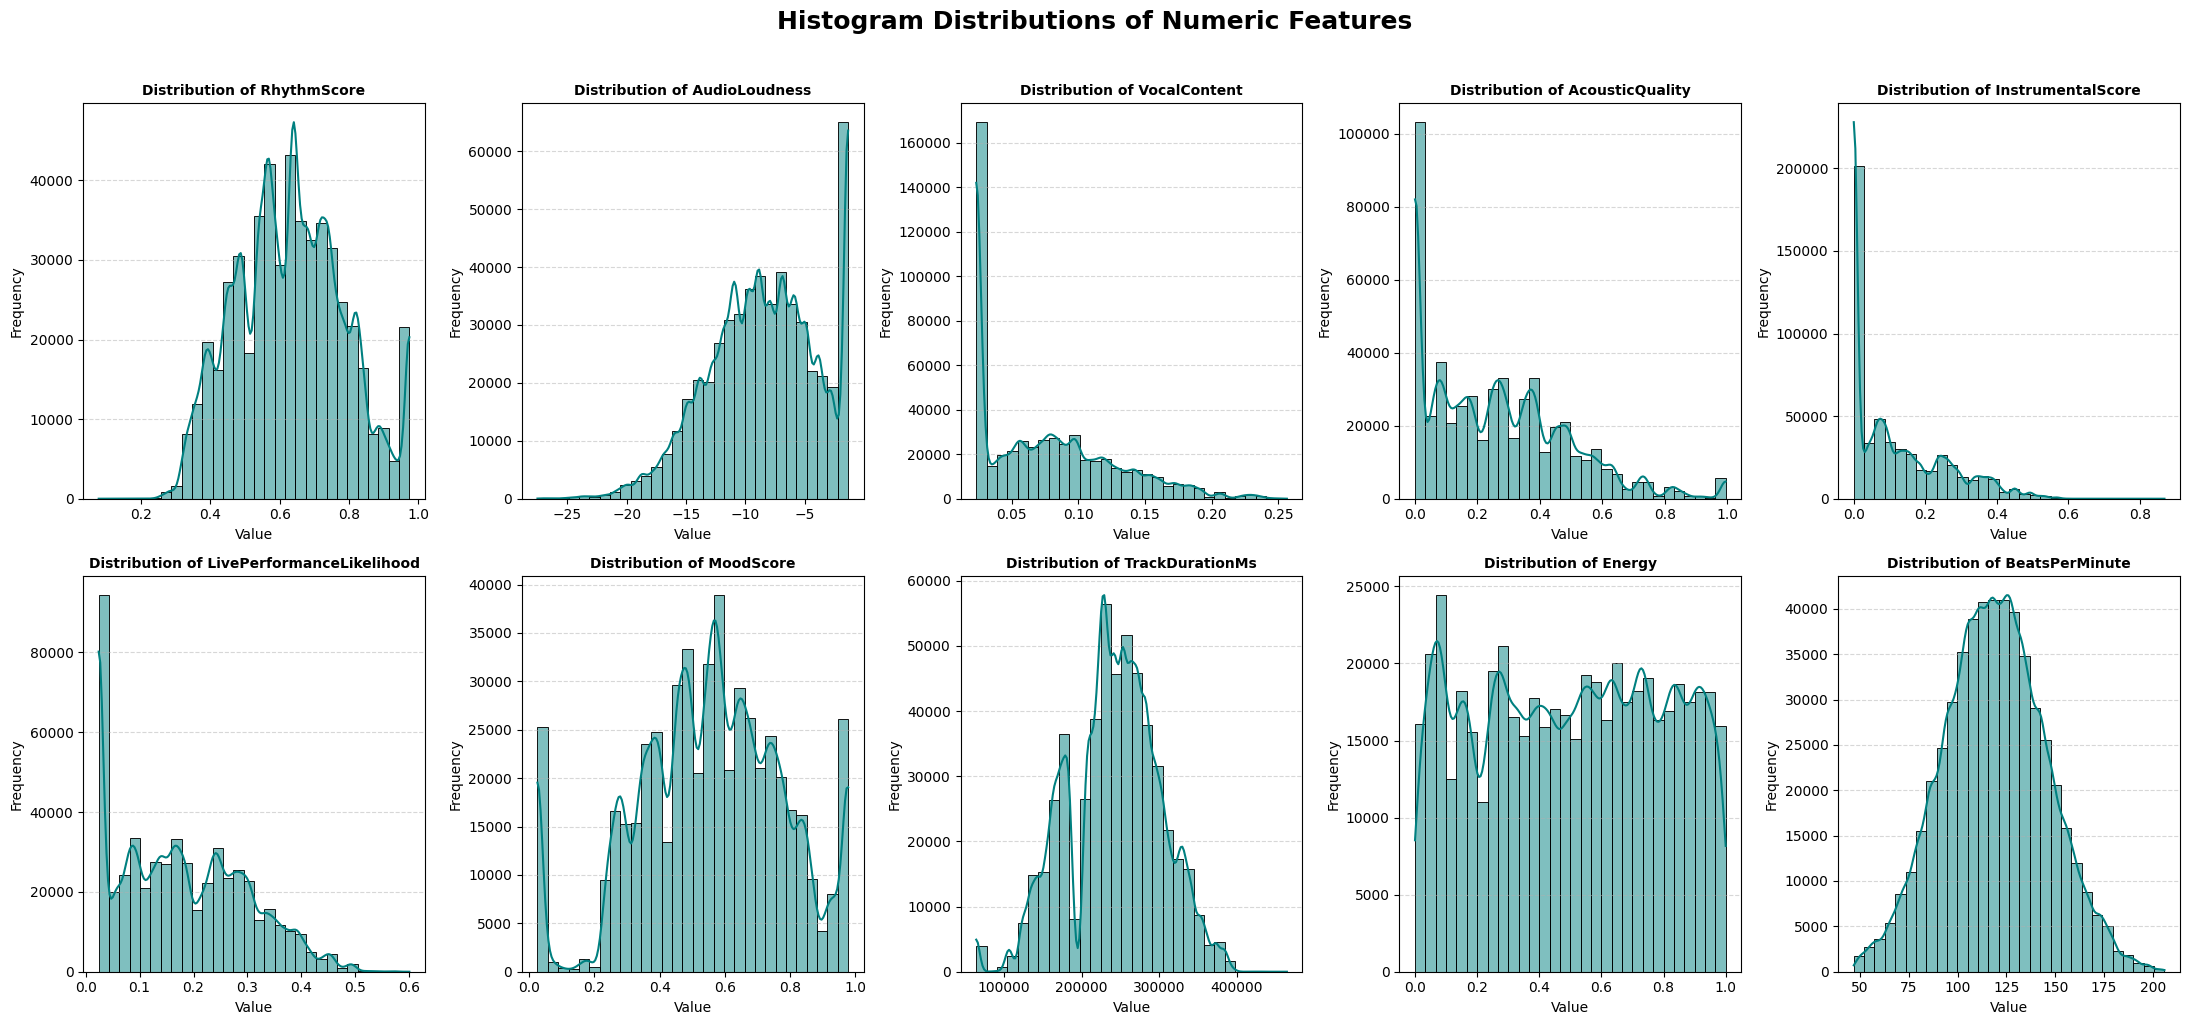

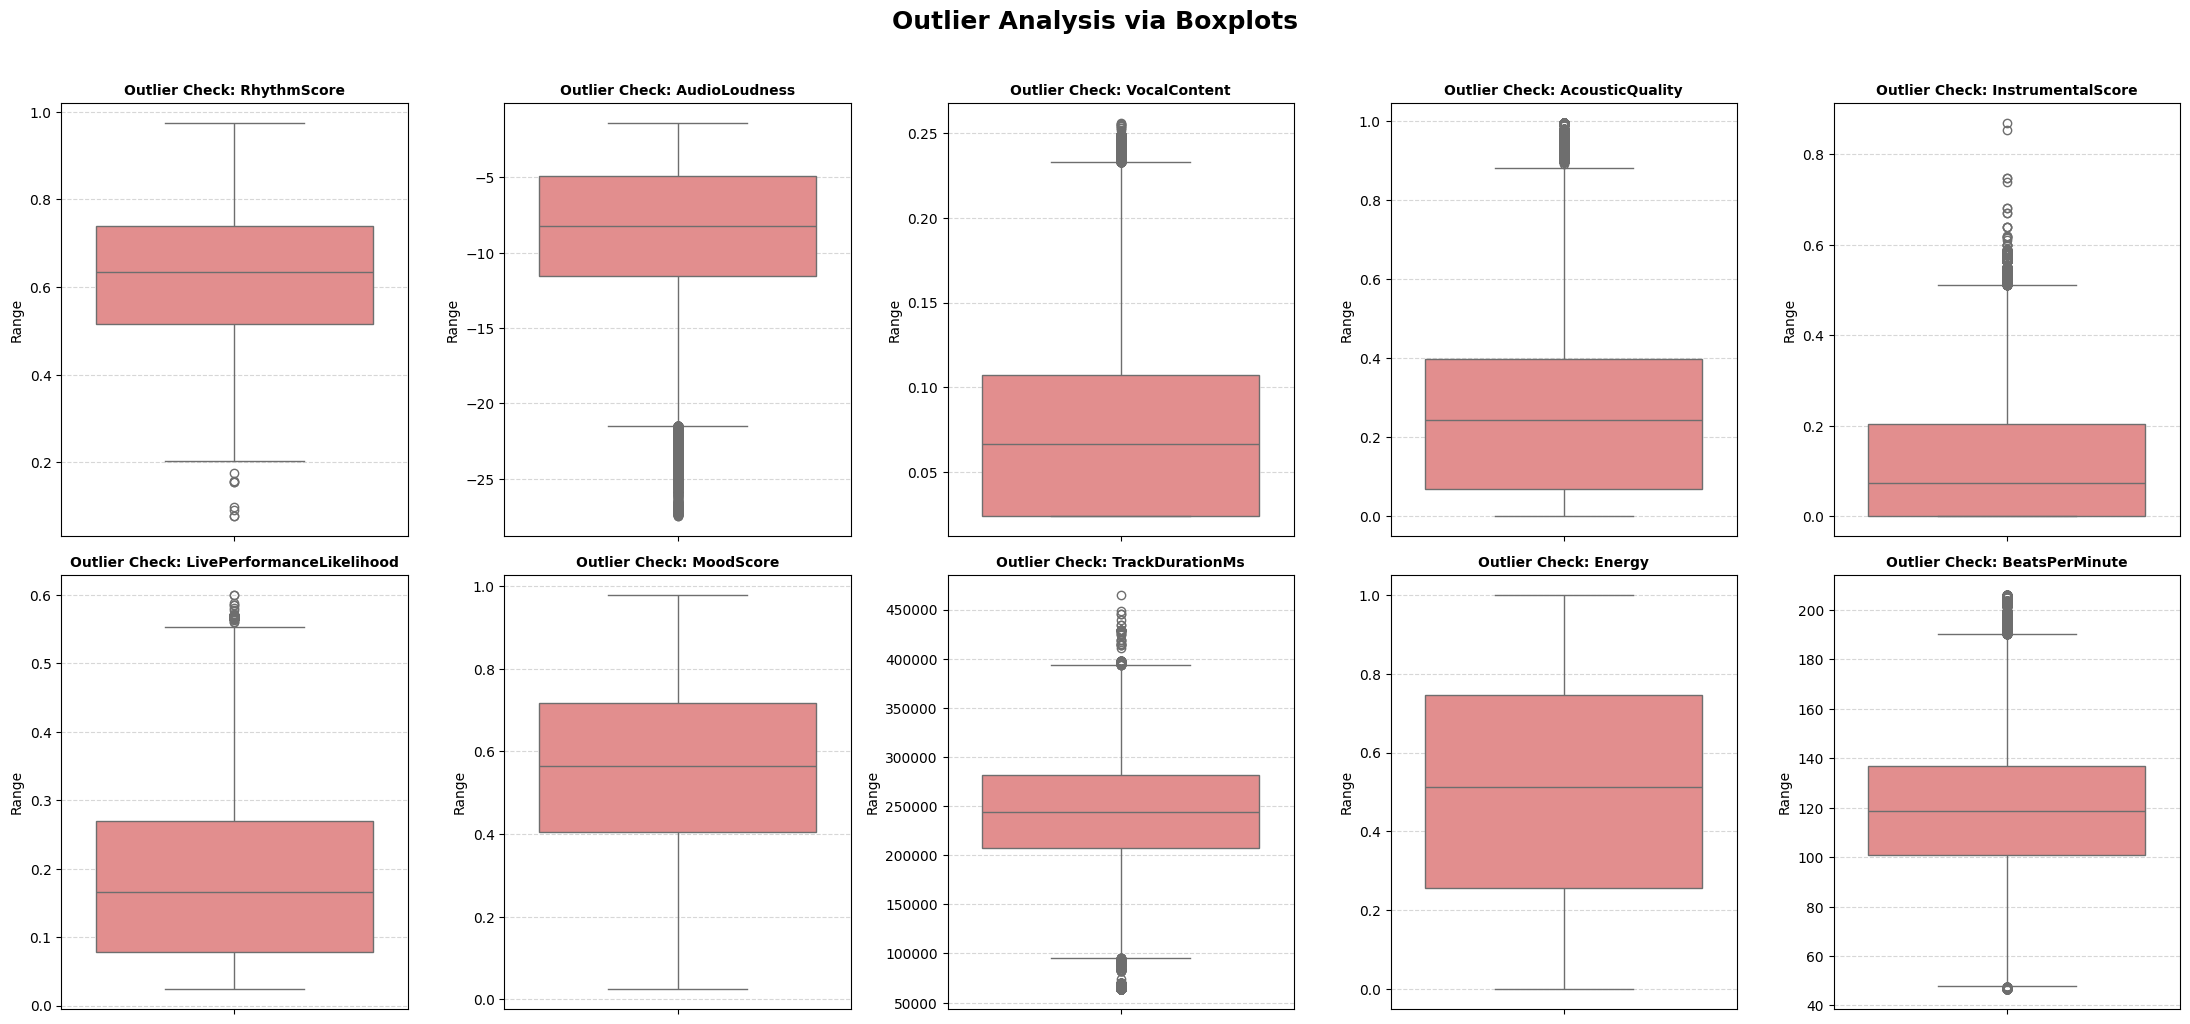

In [13]:
num_features = list(train_df.drop(columns=['id']).columns)

# Histogram
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'Distribution of {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Histogram Distributions of Numeric Features', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# Boxplot
fig, axes = plt.subplots(2, 5, figsize=(22, 10)) 
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=train_df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Outlier Check: {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Range')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Outlier Analysis via Boxplots', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

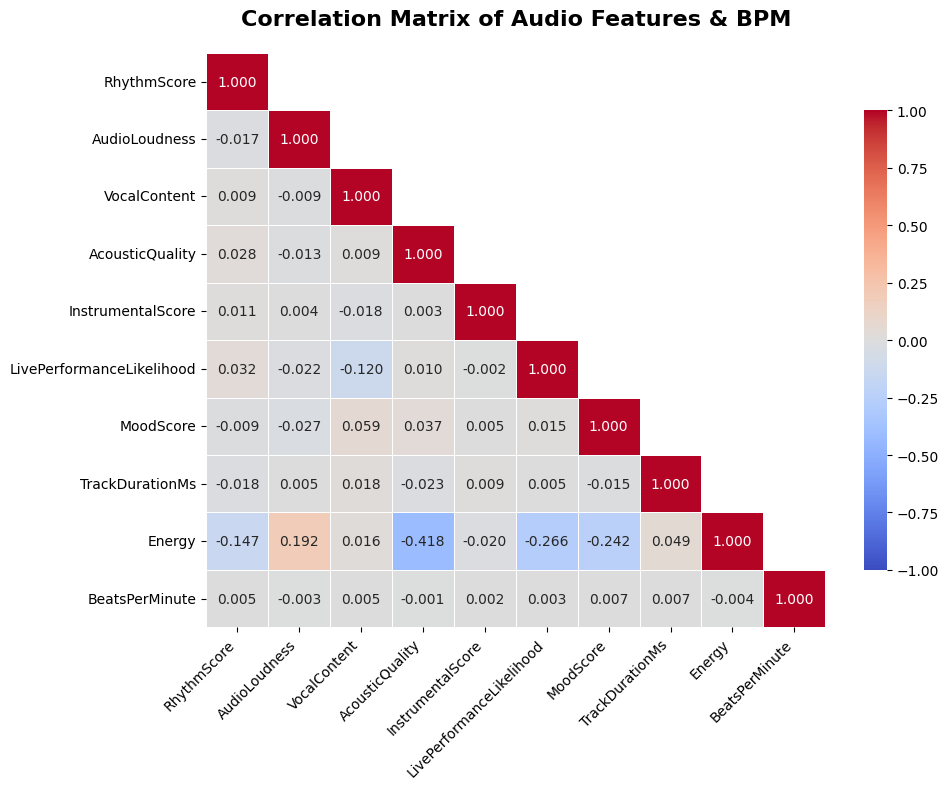

In [14]:
numerical_df = train_df.drop(columns=['id'])

corr_matrix = numerical_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8} 
)

plt.title('Correlation Matrix of Audio Features & BPM', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [15]:
x = train_df.drop(columns=['id', 'BeatsPerMinute'])
y = train_df['BeatsPerMinute']

## 5. Model Training, Optimization & Deployment Strategy

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

def algo_test(x, y):

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)
    
    scaler = MinMaxScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    L = LinearRegression()
    R = Ridge()
    Lass = Lasso()
    E = ElasticNet()
    sgd = SGDRegressor(max_iter=2000, random_state=42) 
    ETR = ExtraTreeRegressor(random_state=42)
    GBR = GradientBoostingRegressor(random_state=42)
    kn = KNeighborsRegressor(n_neighbors=5, n_jobs=-1) 
    ada = AdaBoostRegressor(random_state=42)
    dt = DecisionTreeRegressor(random_state=42)
    xgb = XGBRegressor(n_jobs=-1, random_state=42, tree_method='hist') 
    
    algos = [L, R, Lass, E, sgd, ETR, GBR, kn, ada, dt, xgb]
    algo_names = [
        'Linear', 'Ridge', 'Lasso', 'ElasticNet', 'SGD', 
        'Extra Tree', 'Gradient Boosting', 'KNeighbors', 'AdaBoost', 
        'Decision Tree', 'XGBRegressor'
    ]
    
    r_squared = []
    rmse = []
    mae = []
    
    result = pd.DataFrame(columns=['R_Squared', 'RMSE', 'MAE'], index=algo_names)
    
    
    for algo, name in zip(algos, algo_names):
        print(f"Now training and evaluating: {name}...")
        
        model_fit = algo.fit(x_train_scaled, y_train)
        predictions = model_fit.predict(x_test_scaled)
        
        r_squared.append(r2_score(y_test, predictions))
        rmse.append(mean_squared_error(y_test, predictions) ** 0.5)
        mae.append(mean_absolute_error(y_test, predictions))
        
    rtable = result.assign(R_Squared=r_squared, RMSE=rmse, MAE=mae).sort_values('R_Squared', ascending=False)
    return rtable




In [17]:
report_table = algo_test(x, y)

Now training and evaluating: Linear...
Now training and evaluating: Ridge...
Now training and evaluating: Lasso...
Now training and evaluating: ElasticNet...
Now training and evaluating: SGD...
Now training and evaluating: Extra Tree...
Now training and evaluating: Gradient Boosting...
Now training and evaluating: KNeighbors...
Now training and evaluating: AdaBoost...
Now training and evaluating: Decision Tree...
Now training and evaluating: XGBRegressor...


In [18]:
report_table

,R_Squared,RMSE,MAE
Gradient Boosting,0.000486,26.438711,21.179755
Ridge,0.000095,26.443880,21.184139
Linear,0.000095,26.443880,21.184139
SGD,0.000076,26.444129,21.183111
Lasso,-0.000017,26.445357,21.186405
ElasticNet,-0.000017,26.445357,21.186405
AdaBoost,-0.001195,26.460933,21.202673
XGBRegressor,-0.008001,26.550723,21.263813
KNeighbors,-0.198229,28.947810,23.150220
Decision Tree,-1.104281,38.361686,30.682897


In [19]:
x_train = train_df.drop(columns=['id', 'BeatsPerMinute'])
y_train = train_df['BeatsPerMinute']
x_test = test_df.drop(columns=['id'])

In [20]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [21]:
gbr = GradientBoostingRegressor(random_state=42)

In [22]:
gbr.fit(x_train_scaled, y_train)

GradientBoostingRegressor(random_state=42)

In [23]:
gbr_preds = gbr.predict(x_test_scaled)

In [24]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'BeatsPerMinute': gbr_preds
})

submission.to_csv('submission.csv', index=False)

In [28]:
joblib.dump(gbr, 'BPM_GB.joblib')
joblib.dump(scaler, 'BPM_GB_minmax_scaler.joblib')

['BPM_GB_minmax_scaler.joblib']

In [29]:
with open('BPM_GB.pkl', 'wb') as model_file:
    pickle.dump(gbr, model_file)

with open('BPM_GB_minmax_scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)
